Skin Cancer Disease Analysis Using Advanced DeepLearning

Phase 1-Data Understanding

import libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


PIL library is used for read image  files

Load The Datasets

In [2]:
data=pd.read_csv("../dataset/HAM10000_metadata.csv")

Display the first five rows 

In [3]:
data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:
data.shape

(10015, 7)

View the columns name

In [5]:
data.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='str')

dx is a target column

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


Analysing the missing values in the datasets

In [7]:
data.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

Only the "age" have 57 missing values.

In [8]:
data.describe(include="all")

,lesion_id,image_id,dx,dx_type,age,sex,localization
count,10015,10015,10015,10015,9958.000000,10015,10015
unique,7470,10015,7,4,NaN,3,15
top,HAM_0003789,ISIC_0027419,nv,histo,NaN,male,back
freq,6,1,6705,5340,NaN,5406,2192
mean,NaN,NaN,NaN,NaN,51.863828,NaN,NaN
std,NaN,NaN,NaN,NaN,16.968614,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,40.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN


The dataset is imbalanced, because one class (nv) has 6,705 images.

In [32]:
data["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Visualize the target column using countplot.

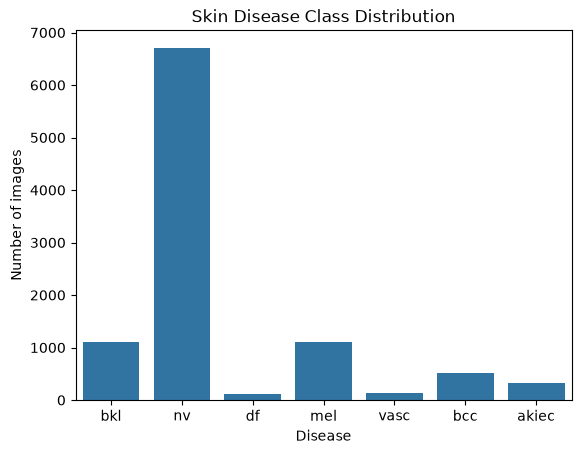

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(data=data,x="dx")
plt.title("Skin Disease Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of images")
plt.show()

create the image path

In [11]:
image1="../dataset/ham10000_images_part_1"
image2="../dataset/ham10000_images_part_2"

create a get_image_path() method for using two images file.

In [12]:
def get_image_path(image_id):
    path1=os.path.join(image1,image_id+".jpg")
    if os.path.exists(path1):
        return path1
    return os.path.join(image2,image_id+".jpg")

create a new column in the datasets for images 

In [13]:
data["image_path"]=data["image_id"].apply(get_image_path)

In [14]:
data.shape

(10015, 8)

In [15]:
data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../dataset/ham10000_images_part_1/ISIC_0027419...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../dataset/ham10000_images_part_1/ISIC_0025030...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../dataset/ham10000_images_part_1/ISIC_0026769...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,../dataset/ham10000_images_part_1/ISIC_0025661...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,../dataset/ham10000_images_part_2/ISIC_0031633...


The image_path column is successfully added in the datasets.

Display sample images

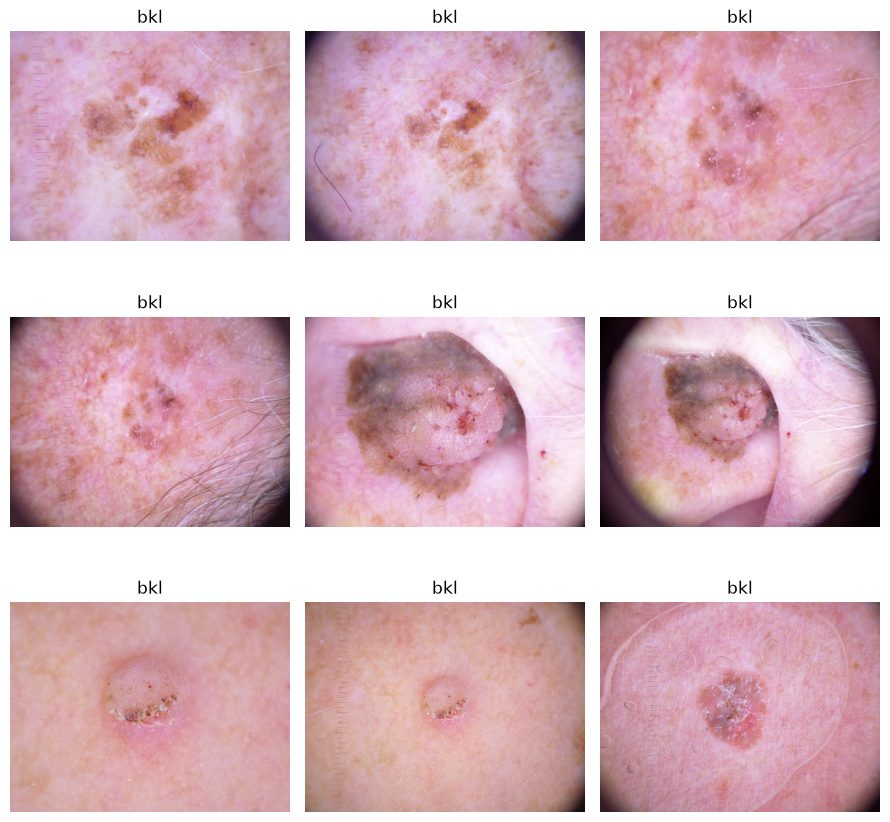

In [16]:
import cv2
plt.figure(figsize=(9,9))
for i in range(9):
    img = cv2.imread(data.loc[i, "image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(data.loc[i, "dx"])
    plt.axis("off")

plt.tight_layout()
plt.show()

Image Resolution Analysis

Because CNN required all image has same size(width,height)

In [17]:
width=[]
height=[]
for path in data["image_path"]:
    img=cv2.imread(path)
    h, w=img.shape[:2] 
    width.append(w)
    height.append(h)
print(width,height)


[600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600,

In [ ]:
resolution=pd.DataFrame({"Width":width,"Height":height})

In [19]:
resolution.head()

,Width,Height
0,600,450
1,600,450
2,600,450
3,600,450
4,600,450


In [20]:
resolution.describe()

,Width,Height
count,10015.0,10015.0
mean,600.0,450.0
std,0.0,0.0
min,600.0,450.0
25%,600.0,450.0
50%,600.0,450.0
75%,600.0,450.0
max,600.0,450.0


In [21]:
resolution.dtypes

Width     int64
Height    int64
dtype: object

All images have same width and height(600X400)

Visualize the Width distribution using histogram

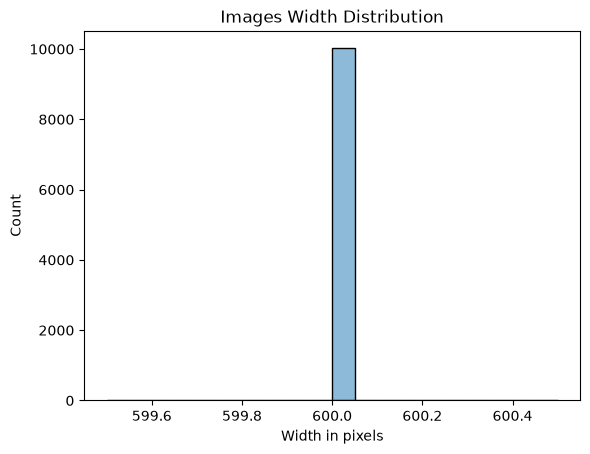

In [22]:
plt.Figure(figsize=(7,7))
sns.histplot(width,bins=20,kde=True)
plt.title("Images Width Distribution")
plt.xlabel("Width in pixels")
plt.ylabel("Count")
plt.show()

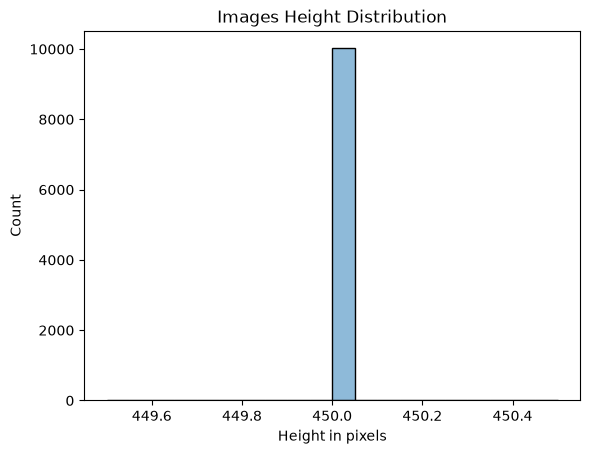

In [23]:
plt.Figure(figsize=(7,7))
sns.histplot(height,bins=20,kde=True)
plt.title("Images Height Distribution")
plt.xlabel("Height in pixels")
plt.ylabel("Count")
plt.show()

Split The data into Train/Validation/Split

In [24]:
from sklearn.model_selection import train_test_split
train_data,test_data=train_test_split(data,test_size=0.15,random_state=42,stratify=data["dx"])

In [25]:
train_data.shape

(8512, 8)

In [26]:
test_data.shape

(1503, 8)

The first call splits the original dataset into training and testing sets. The second call splits the training set into training and validation sets, resulting in three datasets used for model training, tuning, and final evaluation.

In [27]:
train_data,val_data=train_test_split(train_data,test_size=0.1765,random_state=42,stratify=train_data["dx"])

In [28]:
val_data.shape

(1503, 8)

In [29]:
print("Data:",data.shape)
print("Trian_Data:",train_data.shape)
print("Validation_Data:",val_data.shape)
print("Test_Data:",test_data.shape)

Data: (10015, 8)
Trian_Data: (7009, 8)
Validation_Data: (1503, 8)
Test_Data: (1503, 8)


In [30]:
train_data.to_csv("../dataset/train_metadata.csv", index=False)
val_data.to_csv("../dataset/val_metadata.csv", index=False)
test_data.to_csv("../dataset/test_metadata.csv", index=False)

Sucessfully split data into Train/Validation/Test 